In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


from sklearn.linear_model import LinearRegression
from sklearn.svm import LinearSVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor, ExtraTreesRegressor
from sklearn.tree import plot_tree

from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import RidgeCV

## Chargement de données

In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

## Analyse statistique

In [3]:
#Analyse statistique
print(train.describe())

                  id            age    study_hours  class_attendance  \
count  630000.000000  630000.000000  630000.000000     630000.000000   
mean   314999.500000      20.545821       4.002337         71.987261   
std    181865.479132       2.260238       2.359880         17.430098   
min         0.000000      17.000000       0.080000         40.600000   
25%    157499.750000      19.000000       1.970000         57.000000   
50%    314999.500000      21.000000       4.000000         72.600000   
75%    472499.250000      23.000000       6.050000         87.200000   
max    629999.000000      24.000000       7.910000         99.400000   

         sleep_hours     exam_score  
count  630000.000000  630000.000000  
mean        7.072758      62.506672  
std         1.744811      18.916884  
min         4.100000      19.599000  
25%         5.600000      48.800000  
50%         7.100000      62.600000  
75%         8.600000      76.300000  
max         9.900000     100.000000  


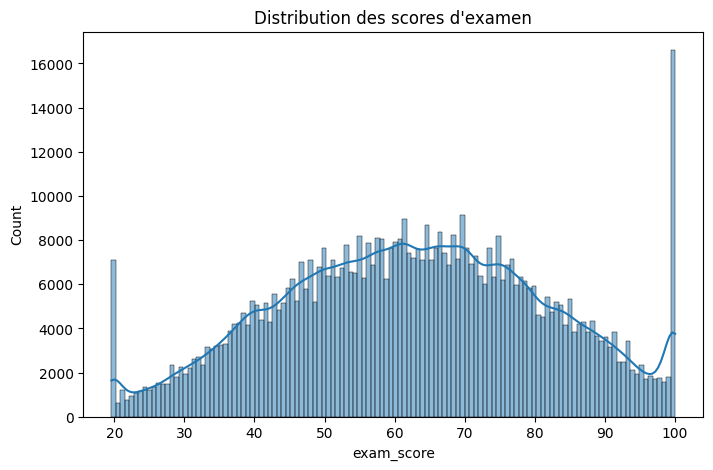

In [4]:
#Distribution de la variable cible
plt.figure(figsize=(8, 5))
sns.histplot(train['exam_score'], kde=True)
plt.title('Distribution des scores d\'examen')
plt.show()


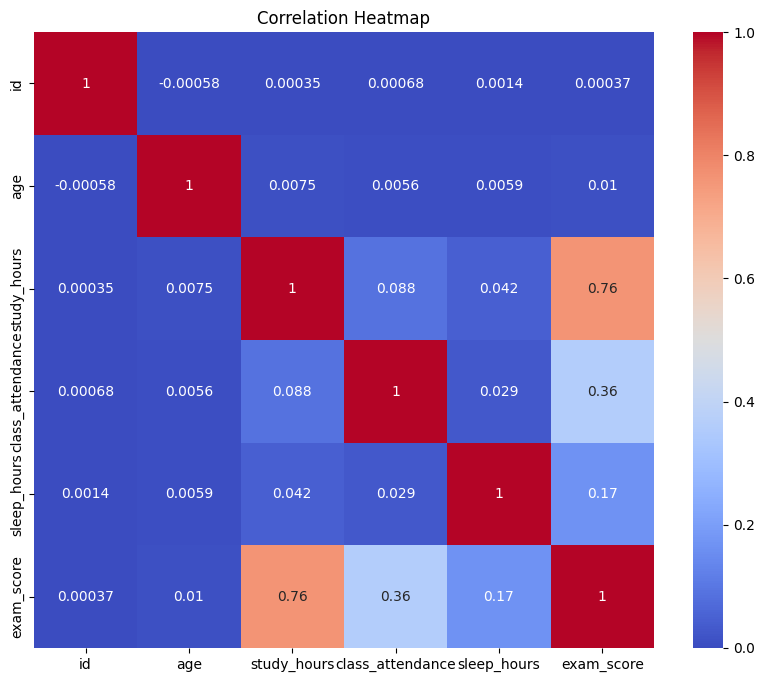

In [5]:
#Matrice de corrélation
corr_matrix = train.select_dtypes(include=['float64', 'int64']).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Prétraitement des données

In [6]:
# Séparation des features et de la cible pour l'entraînement final
X_full = train.drop(columns=['id', 'exam_score'])
y_full = train['exam_score']
X_test = test.drop(columns=['id'])

## Variables numériques : Standardisation

In [7]:
#Le StandardScaler transforme les valeurs pour avoir une moyenne de 0 et un écart-type de 1.
num_cols = ['age', 'study_hours', 'class_attendance', 'sleep_hours']
num_transformer = StandardScaler()

## Variables ordinales : Encodage hiérarchique

In [8]:
#On remplace le texte par des nombres en respectant l'ordre logique.
ordinal_cols = ['facility_rating', 'sleep_quality', 'exam_difficulty']

# Définition de l'ordre pour chaque colonne
facility_cats = ['low', 'medium', 'high']
sleep_cats = ['poor', 'average', 'good']
exam_cats = ['easy', 'moderate', 'hard']

# Création du transformateur
ord_transformer = OrdinalEncoder(categories=[facility_cats, sleep_cats, exam_cats])

## Variables binaires : Encodage 0 ou 1

In [9]:
#On transforme le "no" en 0 et "yes" en 1
binary_cols = ['internet_access']
bin_transformer = OrdinalEncoder(categories=[['no', 'yes']])

## Variables nominales : One-Hot Encoding

In [10]:
#On transforme les variables nominales en variables indicatrices .
nominal_cols = ['gender', 'course', 'study_method']
nom_transformer = OneHotEncoder(handle_unknown='ignore', drop='first')

## Assemblage des transformateurs

In [11]:
#On combine les transformateurs
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('ord', ord_transformer, ordinal_cols),
        ('bin', bin_transformer, binary_cols),
        ('nom', nom_transformer, nominal_cols)
    ])
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e

# Modélisation

## Validation croisée

In [12]:
# Séparation en train/validation locale (80% / 20%) pour pouvoir évaluer le modèle (RMSE et R²)
X, X_val, y, y_val = train_test_split(X_full, y_full, test_size=0.2, random_state=42)
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)
best_models = {}

## Régression linéaire

In [13]:
#On crée un pipeline qui combine le prétraitement, la sélection de caractéristiques et le modèle de régression linéaire.
pipe_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('feature_selection', SelectKBest(score_func=f_regression)),
    ('model', LinearRegression())
])

In [14]:
#On crée le modèle avec tous les variables , en gardant les 10 et 8 colonnes qui ont le plus d'influence sur la variable cible.
param_grid_lr = {'feature_selection__k': ['all', 10, 8]}

In [15]:
#On utilise GridSearchCV pour trouver les meilleures hyperparamètres du modèle de régression linéaire.
gs_lr = GridSearchCV(pipe_lr, param_grid_lr, cv=cv_strategy, scoring='neg_mean_squared_error', n_jobs=-1)
gs_lr.fit(X, y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'feature_selection__k': ['all', 10, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : t

In [16]:
#On affiche les meilleurs paramètres et on stocke le meilleur modèle dans le dictionnaire best_models.
print(f"Meilleurs paramètres LR: {gs_lr.best_params_}")
best_models['LinearRegression'] = gs_lr.best_estimator_

Meilleurs paramètres LR: {'feature_selection__k': 'all'}


## Machine à vecteurs de support

In [17]:
#On crée un pipeline qui combine le prétraitement, la sélection de caractéristiques et le modèle de Support Vector Regressor.
pipe_svm = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearSVR(random_state=42, max_iter=2000))
])

In [18]:
#On crée le modèle pour différents C qui contrôlent la régularisation.
param_grid_svm = {'model__C': [0.1, 1.0, 10.0]}

In [19]:
#On utilise GridSearchCV pour trouver les meilleures hyperparamètres du modèle de Support Vector Regressor.
gs_svm = GridSearchCV(pipe_svm, param_grid_svm, cv=cv_strategy, scoring='neg_mean_squared_error', n_jobs=-1)
gs_svm.fit(X, y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.1, 1.0, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is a

In [20]:
#On affiche les meilleurs paramètres et on stocke le meilleur modèle dans le dictionnaire best_models.
print(f"Meilleurs paramètres SVM: {gs_svm.best_params_}")
best_models['SVM'] = gs_svm.best_estimator_


Meilleurs paramètres SVM: {'model__C': 1.0}


## Arbre de décision

In [21]:
#On crée un pipeline qui combine le prétraitement, la sélection de caractéristiques et le modèle de Decision Tree Regressor.
pipe_dt = Pipeline([
    ('preprocessor', preprocessor),
    ('feature_selection', SelectKBest(score_func=f_regression)),
    ('model', DecisionTreeRegressor(random_state=42))
])

In [22]:
#On crée le modèle pour différents nombres de caractéristiques et différentes profondeurs d'arbre.
param_grid_dt = {
    'feature_selection__k': ['all', 10],#On teste avec toutes les caractéristiques et avec les 10 caractéristiques les plus importantes.
    'model__max_depth': [10, 20, None],#On teste avec des arbres de profondeur limitée et limités.
    'model__min_samples_split': [2, 10, 20]#On teste avec des arbres qui se divisent dès qu'il y a au moins 2 échantillons et 10 échantillons.
}

In [23]:
#On utilise GridSearchCV pour trouver les meilleures hyperparamètres du modèle de Decision Tree Regressor.
gs_dt = GridSearchCV(pipe_dt, param_grid_dt, cv=cv_strategy, scoring='neg_mean_squared_error', n_jobs=-1)
gs_dt.fit(X, y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'feature_selection__k': ['all', 10], 'model__max_depth': [10, 20, ...], 'model__min_samples_split': [2, 10, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the comp

In [24]:
#On affiche les meilleurs paramètres et on stocke le meilleur modèle dans le dictionnaire best_models.
print(f"Meilleurs paramètres DT: {gs_dt.best_params_}")
best_models['DecisionTree'] = gs_dt.best_estimator_

Meilleurs paramètres DT: {'feature_selection__k': 10, 'model__max_depth': 10, 'model__min_samples_split': 20}


## Méthodes ensemblistes


### Forêts aléatoires

In [25]:
#On crée un pipeline qui combine le prétraitement et le modèle de Random Forest Regressor.
pipe_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

In [26]:
#On crée le modèle pour différents nombres d'arbres et différentes profondeurs d'arbre.
param_grid_rf = {
    'model__n_estimators': [10, 30],
    'model__max_depth': [10, 20]
}

In [27]:
#On utilise GridSearchCV pour trouver les meilleures hyperparamètres du modèle de Random Forest Regressor.
gs_rf = GridSearchCV(pipe_rf, param_grid_rf, cv=cv_strategy, scoring='neg_mean_squared_error', n_jobs=-1, verbose=3)
gs_rf.fit(X, y)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [10, 20], 'model__n_estimators': [10, 30]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate 

In [28]:
#On affiche les meilleurs paramètres et on stocke le meilleur modèle dans le dictionnaire best_models.
print(f"Meilleurs paramètres RF: {gs_rf.best_params_}")
best_models['RandomForest'] = gs_rf.best_estimator_

Meilleurs paramètres RF: {'model__max_depth': 20, 'model__n_estimators': 30}


### ExtraTreeRegressor

In [29]:
#On crée un pipeline qui combine le prétraitement et le modèle ExtraTreesRegressor.
pipe_et = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', ExtraTreesRegressor(
        n_jobs=-1,              
        max_features='sqrt',    
        random_state=42
    ))
])

In [30]:
#On crée le modèle pour différents nombres d'arbres et profondeurs.
param_grid_et = {
    'model__n_estimators': [50, 100], # Inutile d'aller trop haut
    'model__max_depth': [15, 20]      # Empêche les arbres de devenir infinis
}

In [31]:
#On utilise GridSearchCV pour trouver les meilleures hyperparamètres du modèle ExtraTreesRegressor.
gs_et = GridSearchCV(pipe_et, param_grid_et, cv=cv_strategy, scoring='neg_mean_squared_error', n_jobs=-1)
gs_et.fit(X, y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [15, 20], 'model__n_estimators': [50, 100]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate

In [32]:
#On affiche les meilleurs paramètres et on stocke le meilleur modèle dans le dictionnaire best_models.
print(f"Meilleurs paramètres ExtraTrees: {gs_et.best_params_}")
best_models['ExtraTrees'] = gs_et.best_estimator_

Meilleurs paramètres ExtraTrees: {'model__max_depth': 20, 'model__n_estimators': 100}


## Boosting de gradients

### CatBoost


In [33]:
# On crée le pipeline avec votre préprocesseur actuel
pipe_cat = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', CatBoostRegressor(random_state=42, verbose=False)) 
])

In [34]:
# Les paramètres à tester (CatBoost est très performant même avec peu de réglages)
param_grid_cat = {
    'model__iterations': [100, 200],      
    'model__learning_rate': [0.05, 0.1], 
    'model__depth': [6, 8] 
}

In [35]:
# Lancement du GridSearch
gs_cat = GridSearchCV(pipe_cat, param_grid_cat, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
gs_cat.fit(X, y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...bose=False))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__depth': [6, 8], 'model__iterations': [100, 200], 'model__learning_rate': [0.05, 0.1]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidat

In [36]:
# Afficher le meilleur score et les meilleurs paramètres
print("Meilleurs paramètres CatBoost:", gs_cat.best_params_)
best_models['CatBoost'] = gs_cat.best_estimator_

Meilleurs paramètres CatBoost: {'model__depth': 8, 'model__iterations': 200, 'model__learning_rate': 0.1}


### LightGBM

In [37]:
#On crée un pipeline qui combine le prétraitement et le modèle LightGBM.
pipe_lgbm = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1))
])

In [38]:
#On crée le modèle pour différents nombres d'arbres, taux d'apprentissage et feuilles
param_grid_lgbm = {
        'model__n_estimators': [200, 400],
        'model__learning_rate': [0.05, 0.1],
        'model__num_leaves': [31, 63],
       'model__subsample': [0.8, 1.0],
}

In [39]:
#On utilise GridSearchCV pour trouver les meilleures hyperparamètres du modèle LightGBM.
gs_lgbm = GridSearchCV(pipe_lgbm, param_grid_lgbm, cv=cv_strategy, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
gs_lgbm.fit(X, y)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...verbose=-1))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.05, 0.1], 'model__n_estimators': [200, 400], 'model__num_leaves': [31, 63], 'model__subsample': [0.8, 1.0]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more mes

In [40]:
#On affiche les meilleurs paramètres et on stocke le meilleur modèle dans le dictionnaire best_models.
print(f"Meilleurs paramètres LightGBM: {gs_lgbm.best_params_}")
best_models['LightGBM'] = gs_lgbm.best_estimator_

Meilleurs paramètres LightGBM: {'model__learning_rate': 0.1, 'model__n_estimators': 400, 'model__num_leaves': 63, 'model__subsample': 0.8}


## Stacking

In [41]:
base_models_complet=[
    ('catboost', gs_cat.best_estimator_),
    ('lgbm', gs_lgbm.best_estimator_),
    ('extra_trees', gs_et.best_estimator_),
    ('linear_reg', gs_lr.best_estimator_),
    ('svr', gs_svm.best_estimator_),
    ('random_forest', gs_rf.best_estimator_),
    ('decision_tree', gs_dt.best_estimator_),
]

In [42]:
#Création du modèle de stacking avec les modèles de base et un Ridge comme modèle finale.
stacking_total = StackingRegressor(
    estimators=base_models_complet,
    final_estimator=RidgeCV(),
    cv=5, 
    n_jobs=-1
)

In [43]:
#Entraînement du modèle de stacking
stacking_total.fit(X_full, y_full)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.","[('catboost', ...), ('lgbm', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA regressor which will be used to combine the base estimators.The default regressor is a :class:`~sklearn.linear_model.RidgeCV`.",RidgeCV()
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",-1
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By 

In [44]:
# Ajout au dictionnaire pour la comparaison
best_models['Stacking_Total'] = stacking_total

# Evaluation des modèles

In [45]:
#On évalue les modèles sur l'ensemble de validation locale et on stocke les résultats dans une liste.
resultats = []

In [46]:
#On évalue chaque modèle sur l'ensemble de validation locale et on calcule le MAE, le RMSE et le R².
for nom_modele, modele in best_models.items():
    val_preds = modele.predict(X_val)
    mae = mean_absolute_error(y_val, val_preds)
    rmse = np.sqrt(mean_squared_error(y_val, val_preds))
    r2 = r2_score(y_val, val_preds)
    resultats.append({
        'Modèle': nom_modele,
        'MAE': round(mae, 3),
        'RMSE': round(rmse, 3),
        'R²': round(r2, 4)
    })

c:\Users\PC\Documents\ENSIIE\MOST\Apprentissage_automatique\Projet\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\PC\Documents\ENSIIE\MOST\Apprentissage_automatique\Projet\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [47]:
#On crée un DataFrame à partir des résultats et on trie par RMSE.
df_resultats = pd.DataFrame(resultats)
df_resultats = df_resultats.sort_values(by='RMSE').reset_index(drop=True)

In [48]:
#On rentre les résultats dans un tableau.
display(df_resultats)
meilleur_modele_nom = df_resultats.iloc[0]['Modèle']
print(f"Le meilleur modèle est : {meilleur_modele_nom}")

,Modèle,MAE,RMSE,R²
0,Stacking_Total,6.694,8.387,0.8022
1,LightGBM,6.984,8.762,0.7841
2,CatBoost,7.021,8.795,0.7825
3,LinearRegression,7.093,8.887,0.7779
4,SVM,7.093,8.892,0.7777
5,ExtraTrees,7.287,9.083,0.7680
6,RandomForest,7.327,9.200,0.7620
7,DecisionTree,7.712,9.637,0.7389


Le meilleur modèle est : Stacking_Total


# Prédiction finale

In [49]:
#On récupère le meilleur modèle pour faire les prédictions sur le test set.
final_model = best_models[meilleur_modele_nom]

In [50]:
#On fait les prédictions sur le test set avec le meilleur modèle.
preds_finales = final_model.predict(X_test)

c:\Users\PC\Documents\ENSIIE\MOST\Apprentissage_automatique\Projet\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [51]:
#On crée un DataFrame pour les résultats de test.
submission = pd.DataFrame({
    'id': test['id'], 
    'exam_score': preds_finales.round(1)
})

In [52]:
#On sauvegarde le DataFrame dans un fichier CSV.
nom_fichier = f'predictions_finales.csv'
submission.to_csv(nom_fichier, index=False)

c:\Users\PC\Documents\ENSIIE\MOST\Apprentissage_automatique\Projet\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


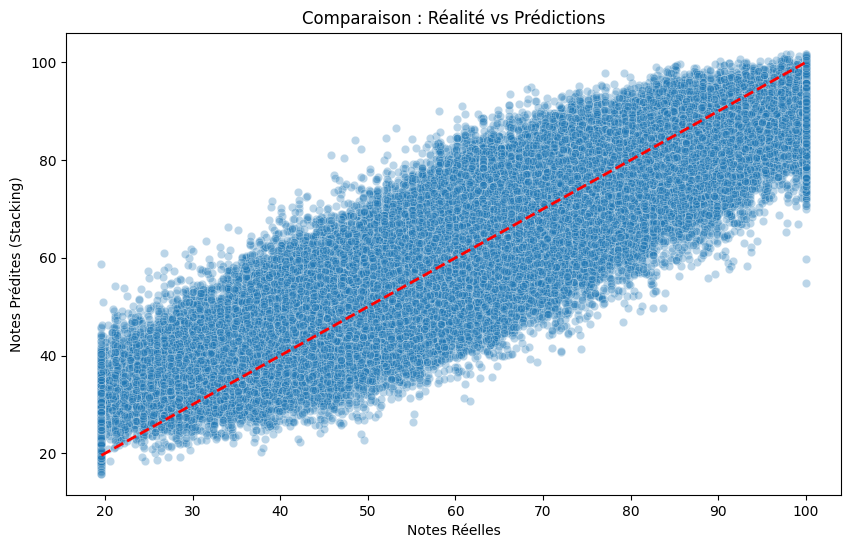

In [53]:
# On récupère les prédictions sur le jeu de validation
y_pred_val = stacking_total.predict(X_val)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_val, y=y_pred_val, alpha=0.3)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], '--r', linewidth=2)
plt.xlabel('Notes Réelles')
plt.ylabel('Notes Prédites (Stacking)')
plt.title('Comparaison : Réalité vs Prédictions')
plt.show()